# 🎓 Predictor de Modalidad de Crédito ICETEX
## Inteligencia Artificial I - Actividad 3
### Algoritmo: Árbol de Decisión

**¿Qué hace este notebook?**
Entrenamos un modelo de Machine Learning que predice la **modalidad del crédito ICETEX**
(Matrícula, Sostenimiento, etc.) según las características del beneficiario colombiano.

**Dataset:** Créditos Otorgados ICETEX
- Fuente: https://web.icetex.gov.co/el-icetex/informacion-institucional/estadisticas-oficiales-icetex
- 109.139 registros reales colombianos
- 13 variables

## Paso 1: Importar librerías

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## Paso 2: Cargar el dataset ICETEX

In [6]:
df = pd.read_csv('../data/raw/Créditos_Otorgados._20260527.csv', encoding='utf-8')

print(f'📊 Filas:    {df.shape[0]:,}')
print(f'📊 Columnas: {df.shape[1]}')
print('\nColumnas:')
for col in df.columns:
    print(f'  → {col}')

df.head()

📊 Filas:    109,139
📊 Columnas: 13

Columnas:
  → VIGENCIA
  → PERIODO OTORGAMIENTO
  → SEXO AL NACER
  → ESTRATO SOCIOECONÓMICO
  → CÓDIGO DEDEPARTAMENTO DE ORIGEN
  → DEPARTAMENTO DE ORIGEN
  → CATEGORÍA DEL MUNICIPIO DE ORIGEN
  → SECTOR IES
  → NIVEL DE FORMACIÓN
  → MODALIDAD DE LÍNEA
  → MODALIDAD DEL CRÉDITO
  → RANGO DEL VALOR TOTAL DESEMBOLSADO
  → NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO


,VIGENCIA,PERIODO OTORGAMIENTO,SEXO AL NACER,ESTRATO SOCIOECONÓMICO,CÓDIGO DEDEPARTAMENTO DE ORIGEN,DEPARTAMENTO DE ORIGEN,CATEGORÍA DEL MUNICIPIO DE ORIGEN,SECTOR IES,NIVEL DE FORMACIÓN,MODALIDAD DE LÍNEA,MODALIDAD DEL CRÉDITO,RANGO DEL VALOR TOTAL DESEMBOLSADO,NÚMERO DE NUEVOS BENEFICIARIOS DE CRÉDITO
0,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formació técnica profesional,PREGRADO,MATRICULA,I,1
1,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,IV,1
2,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,V,2
3,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Tecnológico,PREGRADO,SOSTENIMIENTO,I,1
4,"2,015",2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Universitario,PREGRADO,MATRICULA,I,5


In [7]:
# Ver cuántos registros hay por modalidad (nuestra variable objetivo)
print('Variable objetivo — MODALIDAD DEL CRÉDITO:')
print(df['MODALIDAD DEL CRÉDITO'].value_counts())
print(f'\nTotal de clases: {df["MODALIDAD DEL CRÉDITO"].nunique()}')

Variable objetivo — MODALIDAD DEL CRÉDITO:
MODALIDAD DEL CRÉDITO
MATRICULA        94806
SOSTENIMIENTO    14160
MI PC              173
Name: count, dtype: int64

Total de clases: 3


## Paso 3: Análisis Exploratorio (EDA)

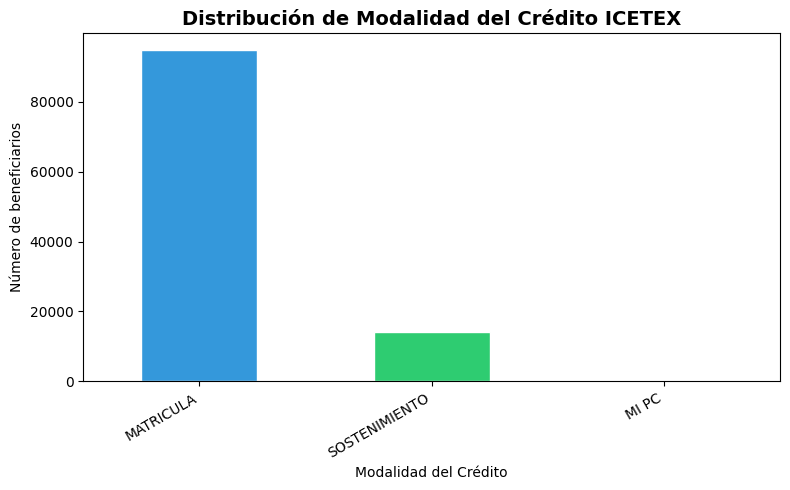

✅ Gráfico guardado en docs/distribucion_target.png


In [8]:
os.makedirs('../docs', exist_ok=True)

# Distribución de la variable objetivo
conteo = df['MODALIDAD DEL CRÉDITO'].value_counts()

plt.figure(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']
conteo.plot(kind='bar', color=colors[:len(conteo)], edgecolor='white')
plt.title('Distribución de Modalidad del Crédito ICETEX', fontsize=14, fontweight='bold')
plt.xlabel('Modalidad del Crédito')
plt.ylabel('Número de beneficiarios')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../docs/distribucion_target.png', dpi=150)
plt.show()
print('✅ Gráfico guardado en docs/distribucion_target.png')

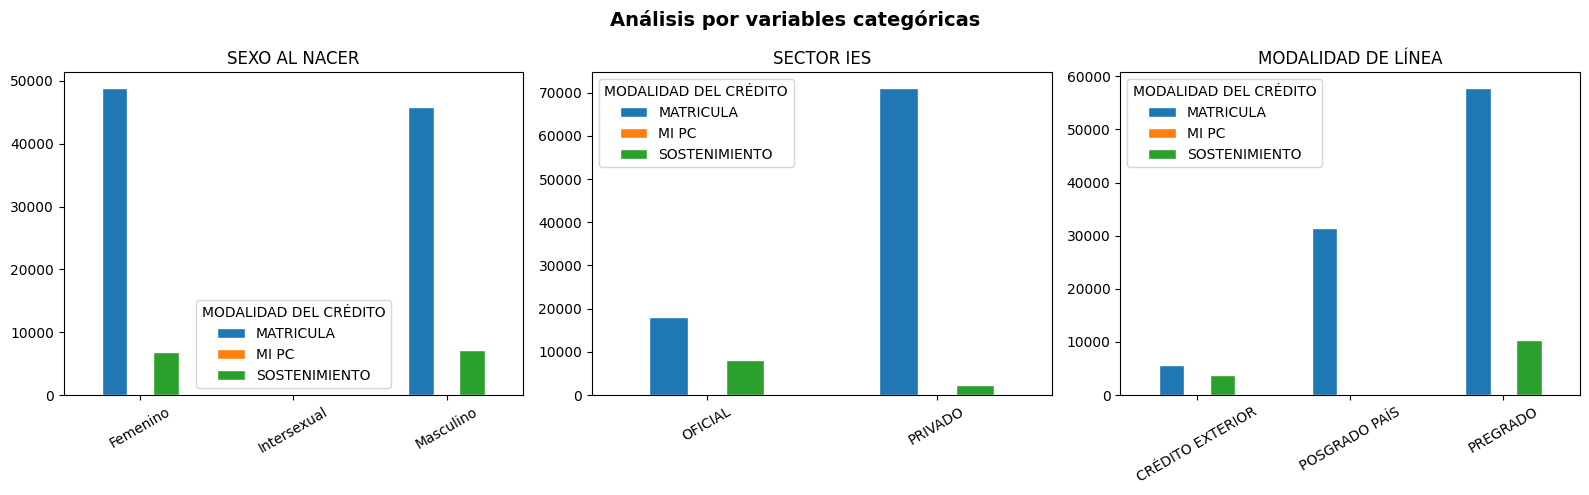

In [9]:
# Distribución por sexo
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Análisis por variables categóricas', fontsize=14, fontweight='bold')

vars_cat = ['SEXO AL NACER', 'SECTOR IES', 'MODALIDAD DE LÍNEA']
for i, col in enumerate(vars_cat):
    pd.crosstab(df[col], df['MODALIDAD DEL CRÉDITO']).plot(
        kind='bar', ax=axes[i], edgecolor='white')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.savefig('../docs/variables_categoricas.png', dpi=150)
plt.show()

<Figure size 1000x500 with 0 Axes>

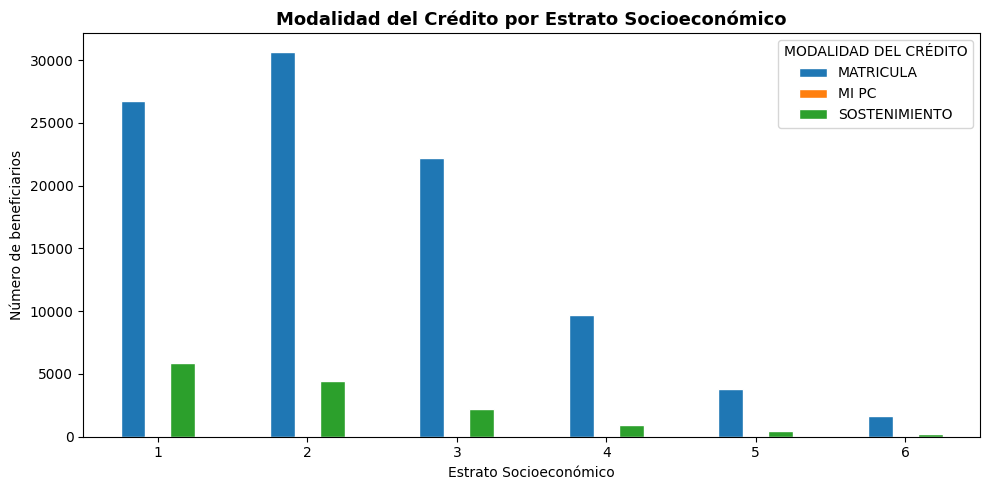

In [10]:
# Distribución por estrato socioeconómico
plt.figure(figsize=(10, 5))
pd.crosstab(df['ESTRATO SOCIOECONÓMICO'], df['MODALIDAD DEL CRÉDITO']).plot(
    kind='bar', figsize=(10,5), edgecolor='white')
plt.title('Modalidad del Crédito por Estrato Socioeconómico', fontsize=13, fontweight='bold')
plt.xlabel('Estrato Socioeconómico')
plt.ylabel('Número de beneficiarios')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../docs/estrato_vs_modalidad.png', dpi=150)
plt.show()

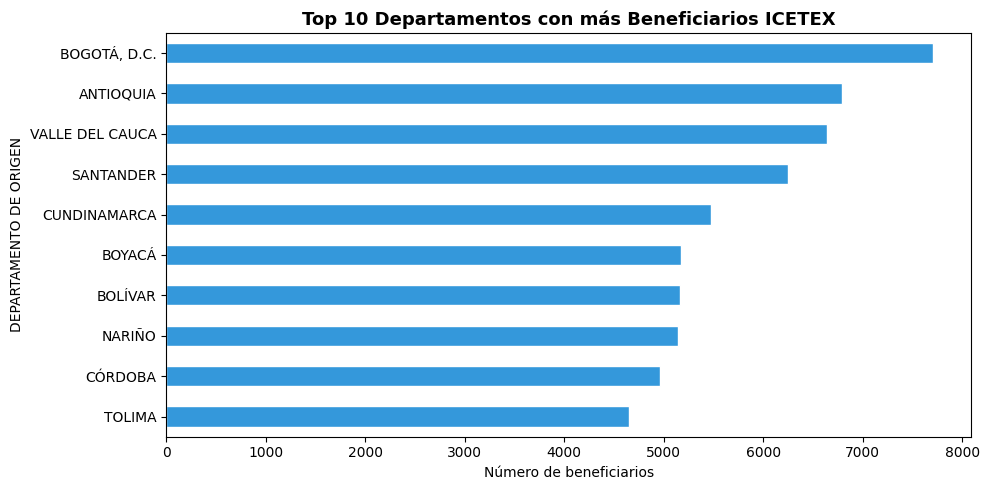

In [11]:
# Top 10 departamentos con más beneficiarios
plt.figure(figsize=(10, 5))
top_deptos = df['DEPARTAMENTO DE ORIGEN'].value_counts().head(10)
top_deptos.plot(kind='barh', color='#3498db', edgecolor='white')
plt.title('Top 10 Departamentos con más Beneficiarios ICETEX', fontsize=13, fontweight='bold')
plt.xlabel('Número de beneficiarios')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../docs/top_departamentos.png', dpi=150)
plt.show()

## Paso 4: Preprocesamiento

Seleccionamos las variables más relevantes para predecir la modalidad del crédito.

In [12]:
df_clean = df.copy()

# Verificar valores nulos
print('Valores nulos por columna:')
nulos = df_clean.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else '  Ningún valor nulo ✅')

Valores nulos por columna:
SECTOR IES    9305
dtype: int64


In [13]:
# Seleccionar features relevantes para el modelo
# Eliminamos columnas que no aportan información predictiva:
# - VIGENCIA y PERIODO OTORGAMIENTO: son fechas, no características del beneficiario
# - CÓDIGO DEDEPARTAMENTO DE ORIGEN: ya tenemos DEPARTAMENTO DE ORIGEN
# - NÚMERO DE NUEVOS BENEFICIARIOS: es un conteo agregado, no una característica individual

FEATURES = [
    'SEXO AL NACER',
    'ESTRATO SOCIOECONÓMICO',
    'DEPARTAMENTO DE ORIGEN',
    'CATEGORÍA DEL MUNICIPIO DE ORIGEN',
    'SECTOR IES',
    'NIVEL DE FORMACIÓN',
    'MODALIDAD DE LÍNEA',
    'RANGO DEL VALOR TOTAL DESEMBOLSADO',
]

OBJETIVO = 'MODALIDAD DEL CRÉDITO'

df_modelo = df_clean[FEATURES + [OBJETIVO]].copy()

print(f'Features seleccionadas: {len(FEATURES)}')
print(f'Registros: {len(df_modelo):,}')
print(f'Variable objetivo: {OBJETIVO}')
print(f'Clases: {df_modelo[OBJETIVO].unique()}')

Features seleccionadas: 8
Registros: 109,139
Variable objetivo: MODALIDAD DEL CRÉDITO
Clases: ['MATRICULA' 'SOSTENIMIENTO' 'MI PC']


In [14]:
# Rellenar nulos si los hay
for col in df_modelo.columns:
    if df_modelo[col].isnull().sum() > 0:
        if df_modelo[col].dtype == 'object':
            df_modelo[col].fillna(df_modelo[col].mode()[0], inplace=True)
        else:
            df_modelo[col].fillna(df_modelo[col].median(), inplace=True)

print(f'✅ Nulos restantes: {df_modelo.isnull().sum().sum()}')

✅ Nulos restantes: 0


In [15]:
# Convertir variables de texto a números con LabelEncoder
le_dict = {}  # Guardamos cada encoder para usarlo en la app

columnas_texto = [
    'SEXO AL NACER',
    'DEPARTAMENTO DE ORIGEN',
    'CATEGORÍA DEL MUNICIPIO DE ORIGEN',
    'SECTOR IES',
    'NIVEL DE FORMACIÓN',
    'MODALIDAD DE LÍNEA',
    'RANGO DEL VALOR TOTAL DESEMBOLSADO',
    'MODALIDAD DEL CRÉDITO',  # También el objetivo
]

for col in columnas_texto:
    le = LabelEncoder()
    df_modelo[col] = le.fit_transform(df_modelo[col].astype(str))
    le_dict[col] = le
    mapeo = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f'  → {col}: {mapeo}')

print('\n✅ Codificación completada')

  → SEXO AL NACER: {'Femenino': 0, 'Intersexual': 1, 'Masculino': 2}
  → DEPARTAMENTO DE ORIGEN: {'AMAZONAS': 0, 'ANTIOQUIA': 1, 'ARAUCA': 2, 'ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA': 3, 'ATLÁNTICO': 4, 'BOGOTÁ, D.C.': 5, 'BOLÍVAR': 6, 'BOYACÁ': 7, 'CALDAS': 8, 'CAQUETÁ': 9, 'CASANARE': 10, 'CAUCA': 11, 'CESAR': 12, 'CHOCÓ': 13, 'CUNDINAMARCA': 14, 'CÓRDOBA': 15, 'GUAINÍA': 16, 'GUAVIARE': 17, 'HUILA': 18, 'LA GUAJIRA': 19, 'MAGDALENA': 20, 'META': 21, 'NARIÑO': 22, 'NORTE DE SANTANDER': 23, 'PUTUMAYO': 24, 'QUINDÍO': 25, 'RISARALDA': 26, 'SANTANDER': 27, 'SUCRE': 28, 'TOLIMA': 29, 'VALLE DEL CAUCA': 30, 'VAUPÉS': 31, 'VICHADA': 32}
  → CATEGORÍA DEL MUNICIPIO DE ORIGEN: {'CIUDADES Y AGLOMERACIONES': 0, 'INTERMEDIO': 1, 'RURAL': 2, 'RURAL DISPERSO': 3}
  → SECTOR IES: {'OFICIAL': 0, 'PRIVADO': 1}
  → NIVEL DE FORMACIÓN: {'Doctorado': 0, 'Educación continuada': 1, 'Especialización médico quirurgica': 2, 'Especialización tecnológica': 3, 'Especialización técnico profesi

In [16]:
# Separar X (features) e y (objetivo)
X = df_modelo[FEATURES]
y = df_modelo[OBJETIVO]

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]:,} registros')
print(f'Prueba:        {X_test.shape[0]:,} registros')
print('\n✅ División completada')

Entrenamiento: 87,311 registros
Prueba:        21,828 registros

✅ División completada


## Paso 5: Entrenar el Árbol de Decisión

In [17]:
model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)

model.fit(X_train, y_train)

print('✅ Modelo entrenado')
print(f'Profundidad del árbol: {model.get_depth()}')
print(f'Número de hojas:       {model.get_n_leaves()}')

✅ Modelo entrenado
Profundidad del árbol: 6
Número de hojas:       49


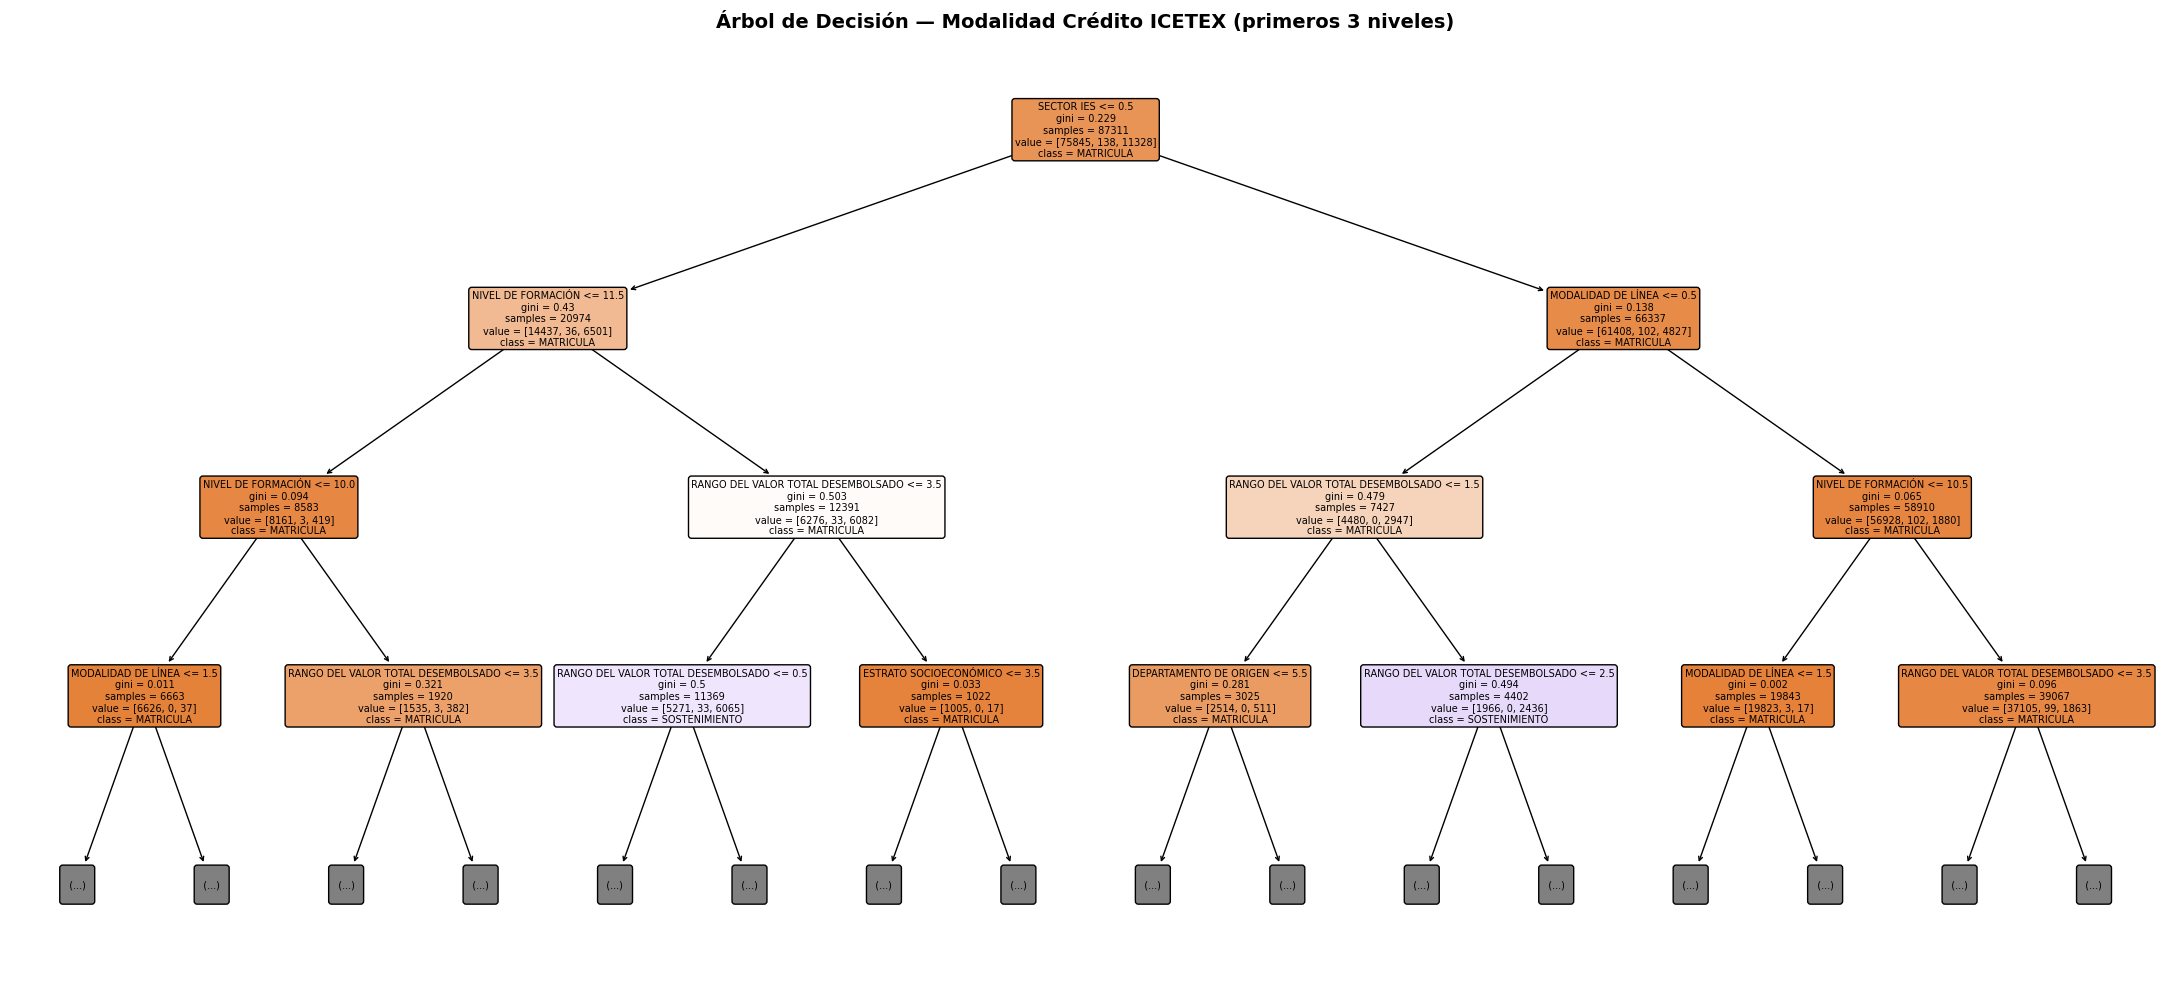

✅ Árbol guardado en docs/arbol_decision.png


In [19]:
# Visualizar el árbol (primeros niveles)
plt.figure(figsize=(22, 10))

# Convertir a lista
clases = le_dict['MODALIDAD DEL CRÉDITO'].classes_.tolist()

plot_tree(
    model,
    feature_names=FEATURES,
    class_names=clases,
    filled=True,
    rounded=True,
    fontsize=7,
    max_depth=3   # Mostrar solo 3 niveles para legibilidad
)

plt.title(
    'Árbol de Decisión — Modalidad Crédito ICETEX (primeros 3 niveles)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    '../docs/arbol_decision.png',
    dpi=100,
    bbox_inches='tight'
)

plt.show()

print('✅ Árbol guardado en docs/arbol_decision.png')

## Paso 6: Evaluación del modelo

In [20]:
y_pred = model.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print('=' * 45)
print('       MÉTRICAS DEL MODELO — ICETEX')
print('=' * 45)
print(f'  Accuracy:   {accuracy:.4f}  ({accuracy*100:.1f}%)')
print(f'  Precision:  {precision:.4f}  ({precision*100:.1f}%)')
print(f'  Recall:     {recall:.4f}  ({recall*100:.1f}%)')
print(f'  F1-Score:   {f1:.4f}  ({f1*100:.1f}%)')
print('=' * 45)

       MÉTRICAS DEL MODELO — ICETEX
  Accuracy:   0.9065  (90.7%)
  Precision:  0.8975  (89.8%)
  Recall:     0.9065  (90.7%)
  F1-Score:   0.9002  (90.0%)


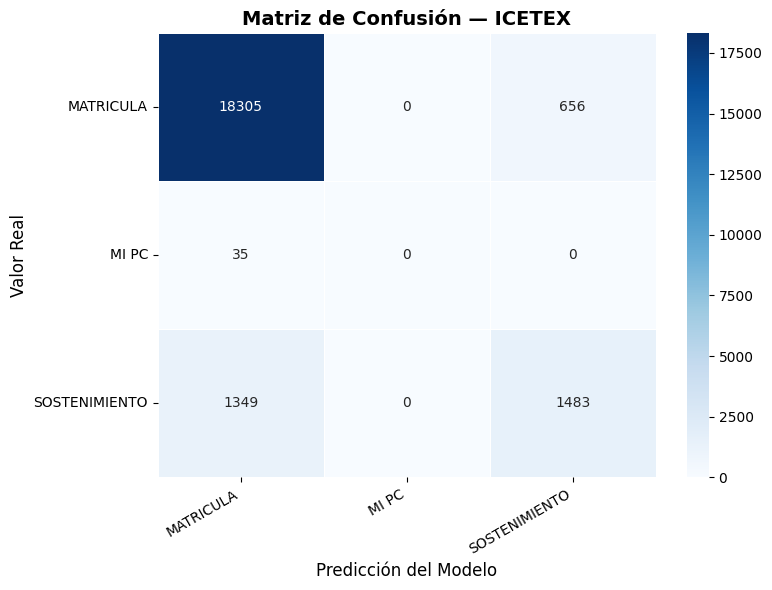

✅ Guardada en docs/matriz_confusion.png


In [21]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases,
            yticklabels=clases,
            linewidths=0.5)
plt.title('Matriz de Confusión — ICETEX', fontsize=14, fontweight='bold')
plt.ylabel('Valor Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../docs/matriz_confusion.png', dpi=150)
plt.show()
print('✅ Guardada en docs/matriz_confusion.png')

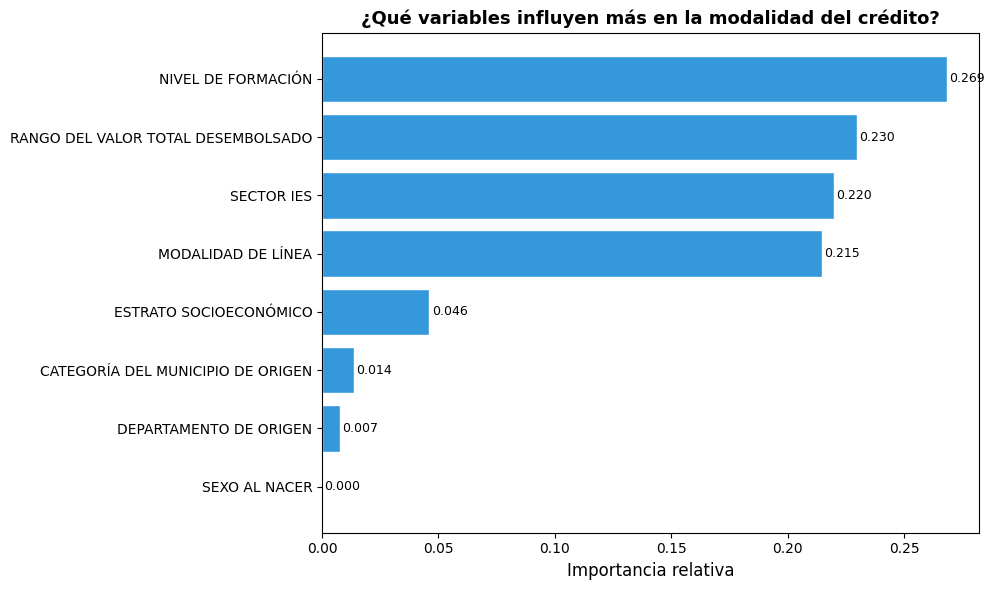

✅ Guardada en docs/feature_importance.png

Variable más importante: NIVEL DE FORMACIÓN
Influencia: 26.9%


In [22]:
# Importancia de variables
importancias = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': model.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(importancias['Feature'], importancias['Importancia'],
                color='#3498db', edgecolor='white')
plt.xlabel('Importancia relativa', fontsize=12)
plt.title('¿Qué variables influyen más en la modalidad del crédito?',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
for bar, val in zip(bars, importancias['Importancia']):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../docs/feature_importance.png', dpi=150)
plt.show()
print('✅ Guardada en docs/feature_importance.png')

print(f'\nVariable más importante: {importancias.iloc[0]["Feature"]}')
print(f'Influencia: {importancias.iloc[0]["Importancia"]*100:.1f}%')

In [23]:
# Reporte completo
print('Reporte completo:')
print(classification_report(y_test, y_pred, target_names=clases))

Reporte completo:
               precision    recall  f1-score   support

    MATRICULA       0.93      0.97      0.95     18961
        MI PC       0.00      0.00      0.00        35
SOSTENIMIENTO       0.69      0.52      0.60      2832

     accuracy                           0.91     21828
    macro avg       0.54      0.50      0.51     21828
 weighted avg       0.90      0.91      0.90     21828



## Paso 7: Guardar el modelo

In [24]:
os.makedirs('../models', exist_ok=True)

# Guardar modelo
joblib.dump(model, '../models/icetex_model.pkl')

# Guardar encoders para usarlos en la app
joblib.dump(le_dict, '../models/label_encoders.pkl')

# Guardar lista de features y clases
joblib.dump(FEATURES, '../models/feature_names.pkl')
joblib.dump(list(clases), '../models/clases.pkl')

print('✅ Archivos guardados en models/:')
print('   → icetex_model.pkl')
print('   → label_encoders.pkl')
print('   → feature_names.pkl')
print('   → clases.pkl')

# Verificar que funciona
modelo_cargado = joblib.load('../models/icetex_model.pkl')
prueba = modelo_cargado.predict([X_test.iloc[0]])
clase_pred = le_dict['MODALIDAD DEL CRÉDITO'].inverse_transform(prueba)
print(f'\n✅ Verificación OK — predicción de prueba: {clase_pred[0]}')

✅ Archivos guardados en models/:
   → icetex_model.pkl
   → label_encoders.pkl
   → feature_names.pkl
   → clases.pkl

✅ Verificación OK — predicción de prueba: MATRICULA
